# ////////////////////////////////////////////////////////////////mycode///////////////////////////////////////////////////////////////


In [1]:
#importing libraries
import os
import numpy as np
import scipy
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
import librosa.display
from scipy.io import wavfile
from scipy import signal

In [2]:
#function to load and process an audio file
def load_and_process_audio(file_path):
    sr, audio = wavfile.read(file_path)
    
    #converting stereo to mono if needed
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)
    
    #normalizing the audio
    audio = audio.astype(float)
    audio = audio / np.max(np.abs(audio))
    
    return sr, audio

In [3]:
#function to compute the FFT of the audio
def compute_fft(audio, sr):
    fft = np.fft.fft(audio)
    freqs = np.fft.fftfreq(len(audio), 1/sr)
    
    #only keep the positive frequencies and their magnitudes
    magnitude = np.abs(fft[:len(fft)//2])
    freqs_positive = freqs[:len(freqs)//2]
    
    return freqs_positive, magnitude

In [4]:
#function to analyze ultrasonic content in audio
def analyze_ultrasonic(audio, sr):
    #computingg FFT and get frequencies and magnitudes
    freqs_positive, magnitude = compute_fft(audio, sr)
    
    #identifing ultrasonic frequencies 
    ultrasonic_mask = freqs_positive > 18000
    ultrasonic_energy = np.sum(magnitude[ultrasonic_mask]**2)
    total_energy = np.sum(magnitude**2)
    
    #calculatting ultrasonic energy ratio
    ultrasonic_ratio = ultrasonic_energy / total_energy if total_energy > 0 else 0
    
    return ultrasonic_energy, total_energy, ultrasonic_ratio, freqs_positive, magnitude

In [5]:
#function to analyze multiple audio files
def analyze_audio_files(audio_files):
    results = []
    
    #looping through each file and process
    for file in audio_files:
        if os.path.exists(file):
            sr, audio = load_and_process_audio(file)
            ultrasonic_energy, total_energy, ultrasonic_ratio, freqs, magnitude = analyze_ultrasonic(audio, sr)
            
            #storing results for the current file
            results.append({
                'filename': file,
                'sample_rate': sr,
                'ultrasonic_energy': ultrasonic_energy,
                'total_energy': total_energy,
                'ultrasonic_ratio': ultrasonic_ratio,
                'freqs': freqs,
                'magnitude': magnitude
            })
        else:
            print(f"File not found: {file}")
    
    return results

In [6]:
#function to plot the results
def plot_results(results):
    num_results = len(results)
    ncols = 2
    nrows = np.ceil(num_results / ncols).astype(int)
    
    #creating subplots for each result
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5))
    axes = axes.flatten()

    #plotting frequency vs magnitude for each result
    for idx, result in enumerate(results):
        ax = axes[idx]
        ax.plot(result['freqs'], result['magnitude'])
        ax.set_title(f"File: {result['filename']}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Magnitude (dB or linear)")
        ax.axvline(x=18000, color='r', linestyle='--', label='18 kHz threshold')
        ax.legend()
    
    #giding extra subplots if there are fewer results
    for idx in range(num_results, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

In [7]:
#function to identify the file with the highest ultrasonic ratio
def identify_suspicious_file(results):
    #finding the file with the maximum ultrasonic ratio
    suspicious_file = max(results, key=lambda x: x['ultrasonic_ratio'])
    return suspicious_file

In [8]:
#function to demodulate audio 
def demodulate_audio(audio, sr, shift_freq=19000, cutoff_freq=4000):
    #create a carrier wave for demodulation
    t = np.arange(len(audio)) / sr
    carrier = np.cos(2 * np.pi * shift_freq * t)
    demodulated = audio * carrier
    
    #applying a low pass filter to extract the secret code
    nyquist = sr / 2
    normalized_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(5, normalized_cutoff, btype='low')
    filtered_audio = signal.filtfilt(b, a, demodulated)
    
    #normalize and clip the filtered audio
    filtered_audio = filtered_audio / np.max(np.abs(filtered_audio))
    filtered_audio = filtered_audio * 2.0
    filtered_audio = np.clip(filtered_audio, -1, 1)
    
    return filtered_audio


In [9]:
#function to save the extracted audio to a file
def save_extracted_audio(filtered_audio, sr, output_filename='extracted_secret_code.wav'):
    #save the filtered audio as a .wav file
    wavfile.write(output_filename, sr, (filtered_audio * 32767).astype(np.int16))
    print(f"Extracted code saved as: {output_filename}")

In [10]:
#function to playback both the original and extracted audio
def playback_audio(original_audio, extracted_audio, sr):
    #playing the original suspicious audio
    print("\nOriginal suspicious audio:")
    display(ipd.Audio(original_audio, rate=sr))

    #playing the extracted (audible) secret code
    print("\nExtracted secret code (audible):")
    display(ipd.Audio(extracted_audio, rate=sr))

In [11]:
#Main function 
def main():
    #path to the audio files
    audio_directory = './audio_files/'
    audio_files = [os.path.join(audio_directory, file) for file in os.listdir(audio_directory) if file.endswith('.wav')]

    #displayig analysis information
    print("ANALYZING AUDIO FILES FOR ULTRASONIC CONTENT")

    #analyze the audio files
    results = analyze_audio_files(audio_files)

    #plot the analysis results
    plot_results(results)

    #identifying the suspicious file with the highest ultrasonic ratio
    suspicious_file = identify_suspicious_file(results)
    print(f"\nSuspicious File: {suspicious_file['filename']}")
    print(f"Ultrasonic Ratio: {suspicious_file['ultrasonic_ratio']:.6f}")

    #loading and process the suspicious audio file
    sr, audio = load_and_process_audio(suspicious_file['filename'])

    #demodulate the audio to extract the secret code
    extracted_audio = demodulate_audio(audio, sr)

    #save the extracted secret code to a file
    save_extracted_audio(extracted_audio, sr)

    #play the original and extracted audio
    playback_audio(audio, extracted_audio, sr)

ANALYZING AUDIO FILES FOR ULTRASONIC CONTENT


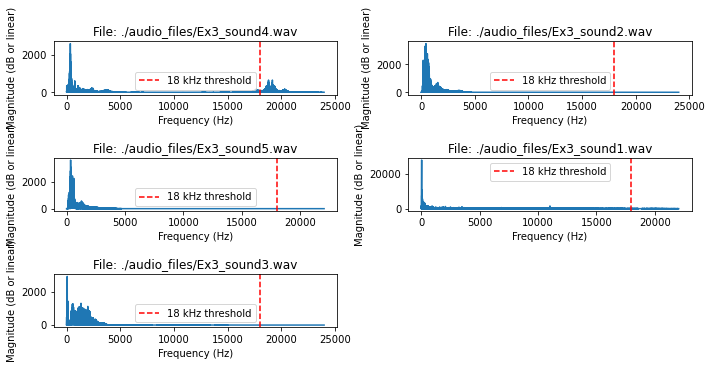


Suspicious File: ./audio_files/Ex3_sound4.wav
Ultrasonic Ratio: 0.158607
Extracted code saved as: extracted_secret_code.wav

Original suspicious audio:



Extracted secret code (audible):


In [12]:
# Run the main function
if __name__ == "__main__":
    main()

# ////////////////////////////////////////////////////////////////mycode///////////////////////////////////////////////////////////////
